# 04 — Stockout Analysis

## GulfMart Retail Inventory Analytics

**True stockout events in this dataset are zero.** Across all 10.96M
`fact_inventory` rows, `stockout_event` is never True and `closing_stock`
never goes negative (confirmed repeatedly in validation runs throughout
this project). A notebook that tried to analyze "which products stock
out most" against data with no stockouts would be either empty or,
worse, tempted into manufacturing a false finding. This notebook does
neither -- it explains *why* stockouts are zero, analyzes the closest
real signal that does exist, and adds a clearly-labeled what-if stress
test to estimate what conditions *would* produce stockouts.

**Why stockouts are exactly zero -- two reasons, not one:**

1. **Architectural:** `fact_sales` quantities are generated independently
   of inventory levels (a Poisson draw on `demand_intensity`, uncapped by
   stock on hand). The inventory model then subtracts that demand from
   stock unconditionally. If demand had ever genuinely exceeded supply,
   `closing_stock` would go negative -- and validation confirms it never
   does, anywhere, in 10.96M rows.
2. **Empirical:** `03_inventory_kpis.ipynb` found systemic, severe
   overstock (annualized turnover ~0.0035, 99.2% of products flagged
   excess inventory) driven by supplier minimum-order-quantities flooring
   every replenishment order well above actual slow-moving demand. Supply
   is so abundant everywhere that demand never comes close to exhausting
   it.

**What this notebook analyzes instead:**

1. `low_stock_event` (`closing_stock <= reorder_point`, but still > 0) --
   the closest available near-miss / risk-proximity signal, broken down
   by demand class, category, store type, region, and supplier lead-time.
2. **What-if stress test** (per your request): a simplified sensitivity
   proxy estimating how many product-store combinations *would* have
   gone negative under a demand spike or a safety-stock cut.

**Stress-test limitation, stated plainly:** this is a **static
sensitivity check against each combination's actual historical worst
moment** (`min_closing_stock`), not a dynamic re-simulation of the full
3-year trajectory. It does not recompute how a smaller safety stock
would have changed order *sizes*, or how a sustained demand spike would
trigger earlier/larger reorders -- both would ripple forward and change
every subsequent day. It answers "how fragile was the worst moment that
actually happened," which is a real and useful signal, but a lower bound
-- not a full counterfactual. See `src/stockout_analysis.py` docstrings
for the exact formulas.


## 1. Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"
DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_CLEANED_DIR = PROJECT_ROOT / "data" / "cleaned"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from stockout_analysis import (
    build_combo_summary,
    summarize_low_stock_by,
    stress_test_demand_spike,
    stress_test_safety_stock_cut,
)

print(f"Project root: {PROJECT_ROOT}")


Project root: d:\GitHub\retail-inventory-analytics


## 2. Load Data

In [2]:
dim_product = pd.read_csv(DATA_CLEANED_DIR / "dim_product.csv")
dim_store = pd.read_csv(DATA_CLEANED_DIR / "dim_store.csv")
dim_supplier = pd.read_csv(DATA_CLEANED_DIR / "dim_supplier.csv")
fact_inventory = pd.read_csv(DATA_RAW_DIR / "fact_inventory.csv.gz")

print(f"dim_product:    {len(dim_product):,} rows")
print(f"dim_store:      {len(dim_store):,} rows")
print(f"dim_supplier:   {len(dim_supplier):,} rows")
print(f"fact_inventory: {len(fact_inventory):,} rows")


dim_product:    500 rows
dim_store:      20 rows
dim_supplier:   30 rows
fact_inventory: 10,960,000 rows


## 3. Confirm the Zero-Stockout Finding

Reproduced directly here, not just asserted, so this notebook stands on
its own evidence.

In [3]:
true_stockout_events = fact_inventory["stockout_event"].sum()
negative_closing_stock_rows = (fact_inventory["closing_stock"] < 0).sum()
low_stock_events = fact_inventory["low_stock_event"].sum()

print(f"True stockout events (closing_stock <= 0):  {true_stockout_events:,}")
print(f"Negative closing_stock rows:                 {negative_closing_stock_rows:,}")
print(f"Low-stock events (<= reorder_point, > 0):     {low_stock_events:,}")
print(f"Low-stock event rate:                         {fact_inventory['low_stock_event'].mean():.4%}")


True stockout events (closing_stock <= 0):  0
Negative closing_stock rows:                 0
Low-stock events (<= reorder_point, > 0):     33,789
Low-stock event rate:                         0.3083%


## 4. Build the Product-Store Combo Summary

One row per (store_id, product_id): worst historical stock level,
low-stock day count/rate, and the static attributes the stress tests
need.

In [4]:
combo_summary = build_combo_summary(fact_inventory, dim_product, dim_store)
combo_summary.head()



Building Product-Store Combo Summary
Combinations summarized: 10,000
Combinations with at least one low-stock day: 2,022


,store_id,product_id,min_closing_stock,low_stock_days,total_days,demand_rate,lead_time_days,safety_stock_units,supplier_id,min_coverage_days,low_stock_pct,product_name,category,demand_class,store_name,store_type,region
0,STORE001,PROD0001,38,14,1096,2.68,14,18.76,SUP021,14.179104,1.277372,Frozen Foods Product 0001,Grocery,Fast-moving,GulfMart Store 001,Express,Southern
1,STORE001,PROD0002,1,0,1096,0.00,9,0.00,SUP008,NaN,0.000000,Accessories Product 0002,Fashion,Slow-moving,GulfMart Store 001,Express,Southern
2,STORE001,PROD0003,25,0,1096,1.20,11,6.00,SUP019,20.833333,0.000000,Paper Products Product 0003,Household,Medium-moving,GulfMart Store 001,Express,Southern
3,STORE001,PROD0004,1,0,1096,0.00,12,0.00,SUP020,NaN,0.000000,Body Care Product 0004,Personal Care,Medium-moving,GulfMart Store 001,Express,Southern
4,STORE001,PROD0005,1,0,1096,0.00,12,0.00,SUP020,NaN,0.000000,Water Product 0005,Beverages,Slow-moving,GulfMart Store 001,Express,Southern


## 5. Low-Stock Risk Breakdowns

Same generic `summarize_low_stock_by()` function applied across several
groupings. `lead_time_bucket` is derived from `SUPPLIER_LEAD_TIME_RANGES`
in `data_generation_config.py` (Local: 2-7 days, Regional: 7-14,
International: 14-30) so the buckets map onto real supplier categories
rather than arbitrary cutoffs.

In [5]:
combo_summary = combo_summary.merge(
    dim_supplier[["supplier_id", "supplier_region", "supplier_status"]],
    on="supplier_id",
    how="left",
)

combo_summary["lead_time_bucket"] = pd.cut(
    combo_summary["lead_time_days"],
    bins=[0, 7, 14, 30],
    labels=["Short (<=7d, Local-like)", "Medium (8-14d, Regional-like)", "Long (>14d, International-like)"],
)

print("Low-stock risk by demand class:")
print(summarize_low_stock_by(combo_summary, "demand_class").to_string(index=False))


Low-stock risk by demand class:
 demand_class  combo_count  combos_with_low_stock  avg_low_stock_pct  avg_min_coverage_days
  Fast-moving         1840                   1077           0.743464              13.540212
Medium-moving         5420                    945           0.316414              20.970012
  Slow-moving         2740                      0           0.000000              45.005797


In [6]:
print("Low-stock risk by category:")
print(summarize_low_stock_by(combo_summary, "category").to_string(index=False))


Low-stock risk by category:
     category  combo_count  combos_with_low_stock  avg_low_stock_pct  avg_min_coverage_days
      Grocery         2280                    654           0.419668              21.116082
Home & Living         1060                    217           0.379510              22.035780
  Electronics         1180                    222           0.317797              21.722974
Personal Care         1000                    220           0.303741              20.827379
      Fashion         1060                    221           0.287151              21.701699
    Beverages         1120                    216           0.242440              21.602377
    Household         1160                    138           0.229990              23.324766
       Beauty         1140                    134           0.177520              20.437916


In [7]:
print("Low-stock risk by store type:")
print(summarize_low_stock_by(combo_summary, "store_type").to_string(index=False))
print()
print("Low-stock risk by region:")
print(summarize_low_stock_by(combo_summary, "region").to_string(index=False))


Low-stock risk by store type:
 store_type  combo_count  combos_with_low_stock  avg_low_stock_pct  avg_min_coverage_days
 E-commerce          500                    106           0.317153              21.617164
Supermarket         4500                    921           0.312956              21.553192
Hypermarket         2500                    510           0.309489              22.473283
    Express         2500                    485           0.296934              20.380928

Low-stock risk by region:
  region  combo_count  combos_with_low_stock  avg_low_stock_pct  avg_min_coverage_days
 Western         3000                    625           0.314112              22.090639
 Central         1000                    203           0.311588              21.273076
Southern         3000                    602           0.307482              21.613340
 Eastern         1500                    301           0.307421              21.192019
Northern         1500                    291           0.2

In [8]:
print("Low-stock risk by supplier lead-time bucket:")
print(summarize_low_stock_by(combo_summary, "lead_time_bucket").to_string(index=False))
print()
print("Low-stock risk by supplier region:")
print(summarize_low_stock_by(combo_summary, "supplier_region").to_string(index=False))


Low-stock risk by supplier lead-time bucket:
               lead_time_bucket  combo_count  combos_with_low_stock  avg_low_stock_pct  avg_min_coverage_days
Long (>14d, International-like)         1820                   1283           1.272860              21.260448
  Medium (8-14d, Regional-like)         4020                    702           0.188065              21.998476
       Short (<=7d, Local-like)         4160                     37           0.002478              21.227005

Low-stock risk by supplier region:
supplier_region  combo_count  combos_with_low_stock  avg_low_stock_pct  avg_min_coverage_days
  International         1820                   1283           1.272860              21.260448
       Regional         4020                    702           0.188065              21.998476
          Local         4160                     37           0.002478              21.227005


## 6. Near-Miss Deep Dive

The specific product-store combinations that came closest to a real
stockout -- highest share of days spent in Low Stock status, and lowest
minimum coverage ever observed.

In [9]:
at_risk = combo_summary[combo_summary["low_stock_days"] > 0]

print(f"Combinations with at least one low-stock day: {len(at_risk):,} of {len(combo_summary):,}")
print()
print("Top 10 combinations by share of days in Low Stock status:")
print(
    at_risk.sort_values("low_stock_pct", ascending=False)[
        ["store_id", "product_id", "product_name", "store_name", "demand_class", "low_stock_pct", "min_coverage_days"]
    ]
    .head(10)
    .to_string(index=False)
)


Combinations with at least one low-stock day: 2,022 of 10,000

Top 10 combinations by share of days in Low Stock status:
store_id product_id                    product_name         store_name  demand_class  low_stock_pct  min_coverage_days
STORE017   PROD0269     Paper Products Product 0269 GulfMart Store 017 Medium-moving       2.554745          21.111111
STORE001   PROD0077            Storage Product 0077 GulfMart Store 001 Medium-moving       2.554745          21.000000
STORE001   PROD0056             Juices Product 0056 GulfMart Store 001   Fast-moving       2.554745          13.761468
STORE020   PROD0377      Smart Devices Product 0377 GulfMart Store 020 Medium-moving       2.554745          21.000000
STORE020   PROD0468     Paper Products Product 0468 GulfMart Store 020 Medium-moving       2.554745          21.000000
STORE020   PROD0367       Beauty Tools Product 0367 GulfMart Store 020   Fast-moving       2.554745          14.033742
STORE005   PROD0468     Paper Products Product

In [14]:
print("Top 10 combinations by lowest minimum coverage days observed (closest to the edge):")
print(
    at_risk.sort_values("min_coverage_days", ascending=True)[
        ["store_id", "product_id", "product_name", "store_name", "demand_class", "min_coverage_days", "low_stock_pct"]
    ]
    .head(10)
    .to_string(index=False)
)


Top 10 combinations by lowest minimum coverage days observed (closest to the edge):
store_id product_id                       product_name         store_name demand_class  min_coverage_days  low_stock_pct
STORE014   PROD0367          Beauty Tools Product 0367 GulfMart Store 014  Fast-moving           6.721387       2.554745
STORE019   PROD0426    Cooking Essentials Product 0426 GulfMart Store 019  Fast-moving           8.073684       1.459854
STORE015   PROD0104 Furniture Accessories Product 0104 GulfMart Store 015  Fast-moving           8.414767       2.554745
STORE009   PROD0367          Beauty Tools Product 0367 GulfMart Store 009  Fast-moving           8.593548       2.554745
STORE016   PROD0367          Beauty Tools Product 0367 GulfMart Store 016  Fast-moving           8.987161       2.554745
STORE007   PROD0426    Cooking Essentials Product 0426 GulfMart Store 007  Fast-moving           9.371166       1.459854
STORE005   PROD0289        Men's Grooming Product 0289 GulfMart Store

## 7. What-If Stress Test: Demand Spike

For each spike factor, how many combinations would have gone negative
at their actual historical worst moment if demand had been that many
times higher for one lead-time window. See the module docstring for the
exact formula and its limitations.

In [10]:
demand_spike_results = stress_test_demand_spike(combo_summary)
demand_spike_results



Stress Test: Demand Spike
    1.5x demand spike: 54 combos (0.54%) would go negative
    2.0x demand spike: 742 combos (7.42%) would go negative
    3.0x demand spike: 3,374 combos (33.74%) would go negative
    5.0x demand spike: 5,890 combos (58.90%) would go negative
   10.0x demand spike: 7,314 combos (73.14%) would go negative


,spike_factor,combos_would_stockout,pct_would_stockout
0,1.5,54,0.54
1,2.0,742,7.42
2,3.0,3374,33.74
3,5.0,5890,58.90
4,10.0,7314,73.14


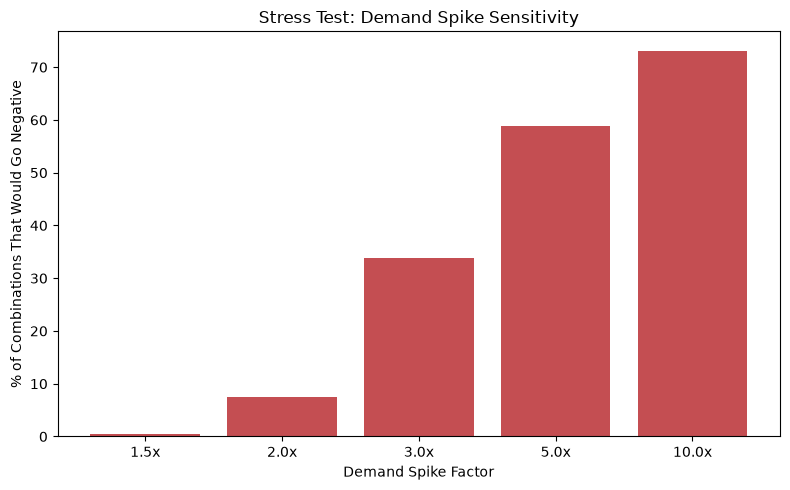

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    demand_spike_results["spike_factor"].astype(str) + "x",
    demand_spike_results["pct_would_stockout"],
    color="#C44E52",
)
ax.set_xlabel("Demand Spike Factor")
ax.set_ylabel("% of Combinations That Would Go Negative")
ax.set_title("Stress Test: Demand Spike Sensitivity")
plt.tight_layout()
plt.show()


## 8. What-If Stress Test: Safety Stock Cut

For each cut percentage, how many combinations would have gone negative
at their actual historical worst moment if that fraction of their
safety-stock cushion had never existed.

In [12]:
safety_stock_results = stress_test_safety_stock_cut(combo_summary)
safety_stock_results



Stress Test: Safety Stock Cut
     25% safety-stock cut: 0 combos (0.00%) would go negative
     50% safety-stock cut: 0 combos (0.00%) would go negative
     75% safety-stock cut: 0 combos (0.00%) would go negative
    100% safety-stock cut: 1 combos (0.01%) would go negative


,safety_stock_cut_pct,combos_would_stockout,pct_would_stockout
0,25.0,0,0.00
1,50.0,0,0.00
2,75.0,0,0.00
3,100.0,1,0.01


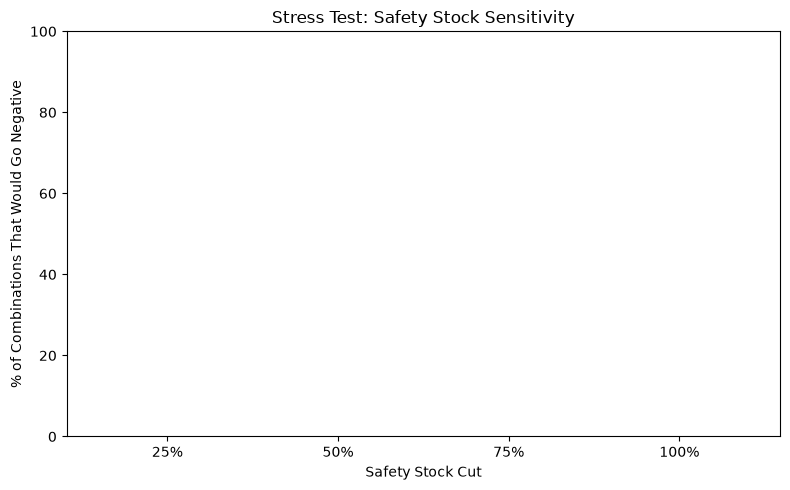

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    safety_stock_results["safety_stock_cut_pct"].astype(int).astype(str) + "%",
    safety_stock_results["pct_would_stockout"],
    color="#DD8452",
)
ax.set_ylim(0, 100)  # match the demand-spike chart's scale so the near-zero result isn't visually exaggerated
ax.set_xlabel("Safety Stock Cut")
ax.set_ylabel("% of Combinations That Would Go Negative")
ax.set_title("Stress Test: Safety Stock Sensitivity")
plt.tight_layout()
plt.show()

## 9. Findings Summary

**Zero real stockouts, confirmed and explained:** 0 true stockout events,
0 negative-inventory rows across 10.96M fact_inventory rows. Root cause
is architectural (demand generation is uncapped by stock on hand) and
empirical (systemic MOQ-driven oversupply, per `03_inventory_kpis.ipynb`).

**Low-stock risk pattern:** 2,022 of 10,000 product-store combinations
(20.2%) experienced at least one low-stock day, but exposure is sharply
concentrated, not evenly spread:

- **By demand class:** Fast-moving products carry nearly all the risk
  (0.74% of days low-stock; 1,077/1,840 combos affected). Slow-moving
  products show **zero** low-stock combinations at all (0/2,740) — the
  same MOQ-oversupply mechanism that causes excess inventory for
  slow-movers makes them structurally incapable of ever approaching
  their reorder point.
- **By supplier lead time — the strongest signal in this analysis:**
  International-supplier combinations show a **1.27% low-stock rate**,
  over **500x higher** than Local-supplier combinations (0.0025%).
  1,283 of 1,820 International-supplied combos were affected at least
  once, vs. 37 of 4,160 Local-supplied combos. Long supplier lead time
  is the dominant driver of whatever real inventory risk exists in this
  system.
- One product, **PROD0367 (Beauty Tools)**, appears repeatedly across
  four different stores in the closest-to-the-edge list (min coverage as
  low as 6.7 days) — a specific, named fragility point worth flagging
  for operational attention, not just an aggregate statistic.

**Stress test — demand spike:** meaningful, interpretable sensitivity.
Negligible impact at 1.5x demand (0.54% of combos would fail), but by
3x demand a third of the network (33.74%) would go negative, and by 10x
nearly three-quarters (73.14%). A 2-3x regional or promotional demand
spike is not an extreme scenario, and this system has materially less
cushion against it than the headline overstock numbers alone would
suggest.

**Stress test — safety stock cut:** near-total insensitivity (0.01% at
a full 100% cut). This is a real, meaningful null result: safety-stock
buffers here represent only 3-7 days of demand (`SAFETY_STOCK_DAYS`),
dwarfed by MOQ-floored base inventory that can represent months to
years of demand for slow-moving products. Safety-stock *policy* is
essentially irrelevant to this system's stockout risk -- the real lever
is MOQ sizing relative to actual demand, not safety-stock days.

**Overall read:** this system has no current stockout problem, but it
is not risk-free -- it has a specific, quantifiable fragility to demand
shocks (especially for fast-moving, internationally-supplied products)
that its severe average overstock conceals. Safety-stock tuning would
not meaningfully address this; MOQ-vs-demand alignment would.

**Next step:** `05_overstock_analysis.ipynb` quantifies the dominant
overstock problem this and `03_inventory_kpis.ipynb` have both pointed
to, with MOQ-vs-demand mismatch as the established root cause.